---
title: Smoothing noisy age-stratified genetic effect estimates
date: 2026-03-17
---

# Smoothing noisy age-stratified genetic effect estimates

We want to represent the pattern of how a SNP effect changes by age, however:

- Effect estimates can be erratic when standard errors are large
- Using z-scores can be more influenced by different sample sizes across ages

Ideally we would use smoothed betas to solve both of these issues. 

- Polynomial meta regression can handle sample overlap which is ideal for hypothesis testing, but imposes a functional form which won't represent the age-trajectory patterns accurately
- Non-parametric smoothing (e.g. LOESS smoothers) can do a better job of capturing the shape without having a statistically clear interpretation

This basic analysis explores how to get smoothed betas.

- Approximate the age-stratified effect estimate results for the FTO variant on BMI
- However I did artificially make the very imprecise estimate for age 90 to be slightly off the obvious trend to try to capture

In [74]:
library(here)
dat <- read.csv(here("posts", "2026-03-17-gxage-smoother", "data.csv"))
str(dat)

'data.frame':	25 obs. of  5 variables:
 $ age       : int  2 4 6 8 10 12 14 16 18 20 ...
 $ snp_effect: num  0.02 0.01 -0.02 -0.04 -0.07 -0.08 -0.09 -0.11 -0.12 -0.1 ...
 $ lower_ci  : num  0.01 0 -0.05 -0.07 -0.11 -0.12 -0.13 -0.16 -0.17 -0.15 ...
 $ upper_ci  : num  0.03 0.02 0.01 -0.01 -0.03 -0.04 -0.05 -0.06 -0.07 -0.05 ...
 $ se        : num  0.0153 0.0153 0.0153 0.0153 0.0204 0.0204 0.0204 0.0255 0.0255 0.0255 ...


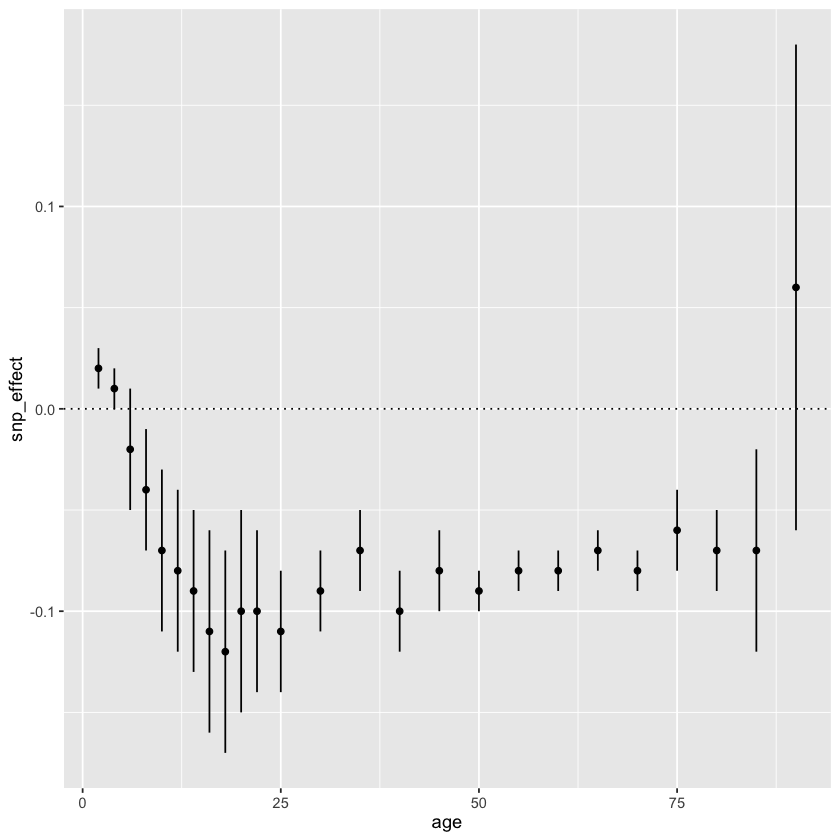

In [75]:
library(ggplot2)
library(dplyr)
dat %>% ggplot(., aes(x=age, y=snp_effect)) +
geom_point() +
geom_errorbar(width=0, aes(ymin = lower_ci, ymax = upper_ci)) +
geom_hline(yintercept=0, linetype="dotted")


Use LOESS to get the smoothed line through these points, with or without weights

In [76]:
l1 <- loess(snp_effect ~ age, data=dat)
dat$loess <- predict(l1, span=0.4)
l2 <- loess(snp_effect ~ age, data=dat, weight=1/dat$se^2, span=0.4)
dat$loessw <- predict(l2)
l3 <- lm(snp_effect ~ poly(age, 3), dat)
dat$poly3 <- predict(l3)
l4 <- lm(snp_effect ~ poly(age, 3), dat, weight=1/dat$se^2)
dat$poly3w <- predict(l4)

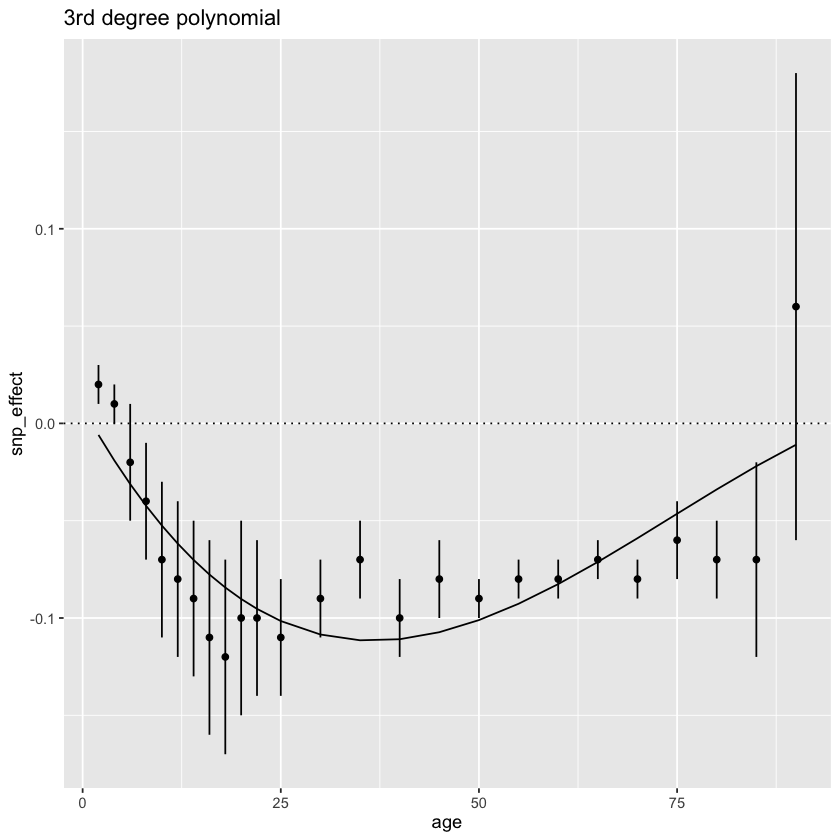

In [77]:
dat %>% ggplot(., aes(x=age, y=snp_effect)) +
geom_point() +
geom_errorbar(width=0, aes(ymin = lower_ci, ymax = upper_ci)) +
geom_line(aes(y=poly3)) +
labs(title="3rd degree polynomial") +
geom_hline(yintercept=0, linetype="dotted")

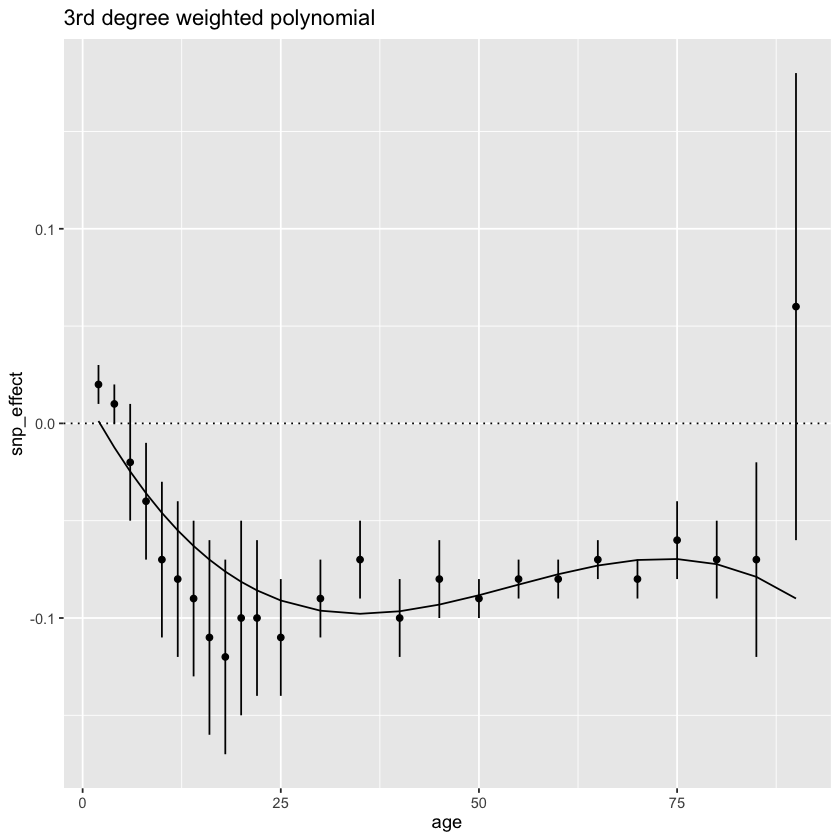

In [78]:
dat %>% ggplot(., aes(x=age, y=snp_effect)) +
geom_point() +
geom_errorbar(width=0, aes(ymin = lower_ci, ymax = upper_ci)) +
geom_line(aes(y=poly3w)) +
labs(title="3rd degree weighted polynomial") +
geom_hline(yintercept=0, linetype="dotted")

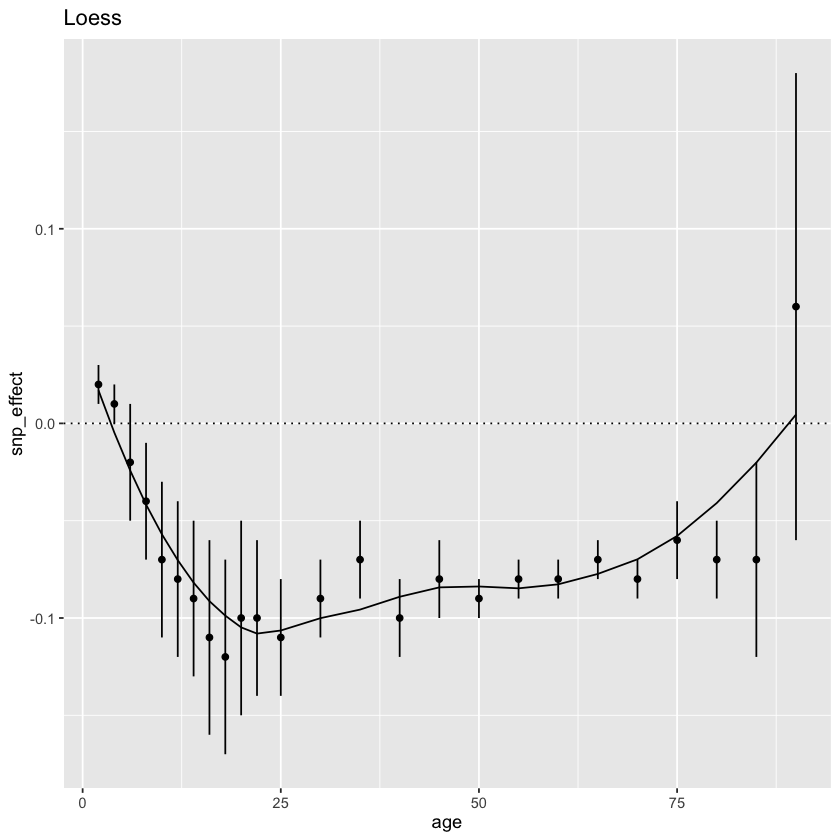

In [79]:
dat %>% ggplot(., aes(x=age, y=snp_effect)) +
geom_point() +
geom_errorbar(width=0, aes(ymin = lower_ci, ymax = upper_ci)) +
geom_line(aes(y=loess)) +
labs(title="Loess") +
geom_hline(yintercept=0, linetype="dotted")

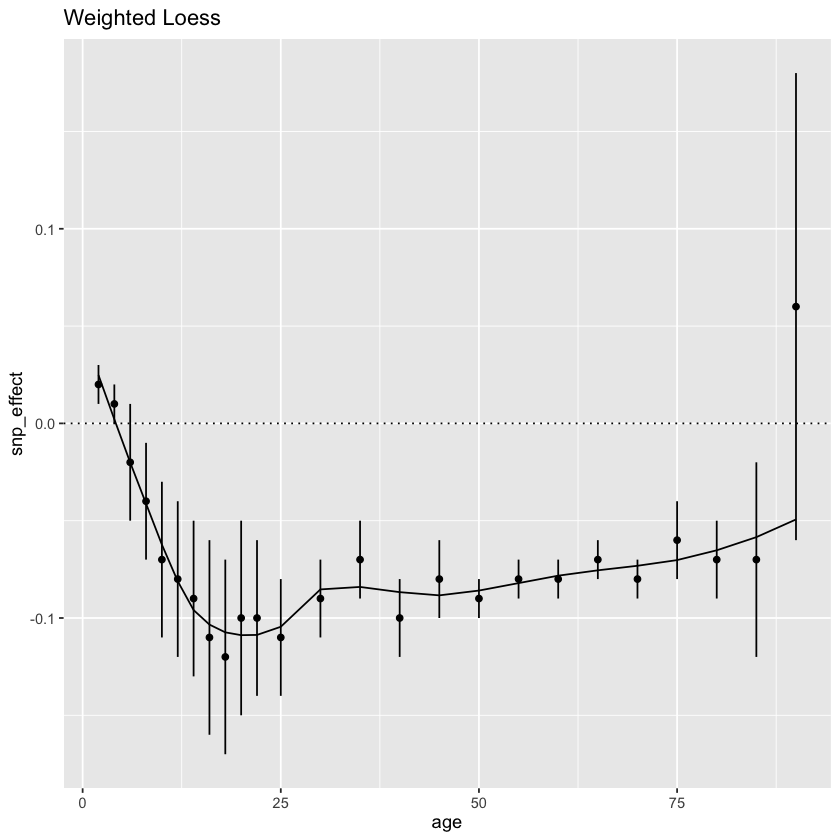

In [80]:
dat %>% ggplot(., aes(x=age, y=snp_effect)) +
geom_point() +
geom_errorbar(width=0, aes(ymin = lower_ci, ymax = upper_ci)) +
geom_line(aes(y=loessw)) +
labs(title="Weighted Loess") +
geom_hline(yintercept=0, linetype="dotted")